
# Contrastive Learning for EEG Task Classification: Size vs. Animacy Judgments

**Pipeline:** self-supervised contrastive pretraining (SimCLR-style, NT-Xent loss) of an EEG
encoder on unlabeled epochs, followed by (a) a frozen **linear probe** and (b) **end-to-end
fine-tuning** to classify each epoch as belonging to a **Size judgment** trial or an
**Animacy judgment** trial. Results are compared against a fully-supervised baseline trained
from scratch (no contrastive pretraining), using the same leakage-free, subject-grouped
evaluation protocol as the existing EEGConformer pipeline.

This notebook is designed to consume the `.npz` output of the existing
`Preprocessing_for_Size_Animacy_Classification` notebook (arrays `X`, `y`, and subject
`groups`, 29-channel sparse whole-head layout, ltpFR/PEERS dataset, 128-channel EGI
HydroCel GSN net). If that file is not found, a synthetic placeholder dataset with the
same shape conventions is generated automatically so every cell below still runs
end-to-end as a working demo — replace `DATA_PATH` with the real preprocessed file to
use it on actual data.

## Why contrastive learning here

- Size/Animacy judgment decoding from EEG typically has **few subjects and limited
  labeled trials per subject** relative to the dimensionality of the signal — exactly the
  regime where self-supervised pretraining tends to help most.
- Contrastive pretraining can use **all epochs, unlabeled** (including epochs from
  training subjects across both conditions) to learn representations invariant to
  nuisance variation (jitter, amplitude drift, channel noise) before ever touching the
  task label.
- It gives a direct, controlled way to test whether representation quality — not just
  classifier capacity — is the bottleneck in the existing chance-level results.

## Standard references this notebook is based on

1. **Mohsenvand, M.N., Izadi, M.R., & Maes, P. (2020).** *Contrastive Representation
   Learning for Electroencephalogram Classification* (SeqCLR). ML4H Workshop, NeurIPS /
   PMLR v136. — Primary methodological reference: extends SimCLR-style contrastive
   learning to EEG with EEG-specific augmentations (amplitude scale, noise, time shift,
   band-stop filtering, channel-wise recombination). The augmentation suite and NT-Xent
   setup below follow this paper's design.
2. **Chen, T., Kornblith, S., Norouzi, M., & Hinton, G. (2020).** *A Simple Framework for
   Contrastive Learning of Visual Representations* (SimCLR). ICML. — Source of the
   NT-Xent (InfoNCE) loss and the two-augmented-views training scheme used here.
3. **Banville, H., Chehab, O., Hyvärinen, A., Engemann, D.-A., & Gramfort, A. (2021).**
   *Uncovering the structure of clinical EEG signals with self-supervised learning.*
   Journal of Neural Engineering. — Alternative EEG-specific pretext tasks (relative
   positioning, temporal shuffling); motivates the sanity/canary checks used below.
4. **Kostas, D., Aroca-Ouellette, S., & Rudzicz, F. (2021).** *BENDR: Using transformers
   and a contrastive self-supervised learning task to learn from massive amounts of EEG
   data.* Frontiers in Human Neuroscience. — Combines contrastive pretraining with
   transformer encoders for EEG; relevant given the existing EEGConformer work, and a
   natural next step (swap the CNN encoder below for the EEGConformer stem).
5. **Contini, E.W., Wardle, S.G., & Carlson, T.A. (2017).** *Decoding the time-course of
   object recognition in the human brain: From visual features to categorical decisions.*
   Neuropsychologia. — Domain reference establishing that animacy and real-world size are
   reliably decodable from EEG, motivating the classification target itself (note: this
   paper decodes *stimulus* animacy/size via LDA, not *task/judgment type* via contrastive
   learning — cited here for domain grounding, not methodology).



## 1. Imports and reproducibility

Standard scientific Python stack plus PyTorch for the encoder/contrastive loss, and
scikit-learn for the linear probe, splitting, and metrics. `SEED` is fixed everywhere
splits or randomness matter, consistent with the leakage-free evaluation approach used in
the existing EEGConformer notebook.


In [1]:

import os
import math
import copy
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cpu



## 2. Configuration

Central place for every hyperparameter. `DATA_PATH` should point at the `.npz` produced
by the preprocessing notebook. `EMBED_DIM` / `PROJ_DIM` follow typical SimCLR sizing
(projection head smaller than the encoder output is not required, but a separate small
projection head is standard practice — see Chen et al. 2020, section 3). Epoch counts are
kept modest so the notebook runs quickly as a demo; increase them for a real run.


In [2]:

CONFIG = {
    # --- data ---
    "DATA_PATH": "preprocessed_size_animacy.npz",  # <-- point this at the real preprocessing output
    "N_CHANNELS_DEFAULT": 29,     # sparse whole-head 29-channel layout used upstream
    "N_TIMES_DEFAULT": 128,       # samples per epoch (synthetic fallback only)
    "SFREQ_DEFAULT": 250.0,       # Hz (synthetic fallback only)

    # --- splitting ---
    "TEST_SIZE": 0.25,            # fraction of SUBJECTS held out for testing
    "N_CV_FOLDS": 4,              # StratifiedGroupKFold folds (clamped to n subjects if needed)

    # --- encoder / contrastive ---
    "F1": 8,                      # temporal filters
    "D": 2,                       # depth multiplier for spatial (depthwise) conv
    "F2": 16,                     # separable conv filters (F1 * D by default)
    "EMBED_DIM": 64,
    "PROJ_DIM": 32,
    "TEMPERATURE": 0.2,           # NT-Xent temperature

    # --- training ---
    "PRETRAIN_EPOCHS": 15,
    "PRETRAIN_BATCH_SIZE": 32,
    "PRETRAIN_LR": 3e-4,

    "PROBE_MAX_ITER": 2000,

    "FINETUNE_EPOCHS": 10,
    "FINETUNE_BATCH_SIZE": 32,
    "FINETUNE_LR": 1e-4,

    "BASELINE_EPOCHS": 15,
    "BASELINE_BATCH_SIZE": 32,
    "BASELINE_LR": 1e-3,
}
print(CONFIG)


{'DATA_PATH': 'preprocessed_size_animacy.npz', 'N_CHANNELS_DEFAULT': 29, 'N_TIMES_DEFAULT': 128, 'SFREQ_DEFAULT': 250.0, 'TEST_SIZE': 0.25, 'N_CV_FOLDS': 4, 'F1': 8, 'D': 2, 'F2': 16, 'EMBED_DIM': 64, 'PROJ_DIM': 32, 'TEMPERATURE': 0.2, 'PRETRAIN_EPOCHS': 15, 'PRETRAIN_BATCH_SIZE': 32, 'PRETRAIN_LR': 0.0003, 'PROBE_MAX_ITER': 2000, 'FINETUNE_EPOCHS': 10, 'FINETUNE_BATCH_SIZE': 32, 'FINETUNE_LR': 0.0001, 'BASELINE_EPOCHS': 15, 'BASELINE_BATCH_SIZE': 32, 'BASELINE_LR': 0.001}



## 3. Load preprocessed data (with synthetic fallback)

Expected `.npz` contents, matching the existing preprocessing notebook's output:

- `X`: array of shape `(n_epochs, n_channels, n_times)` — EEG epochs, already
  per-subject/per-channel normalized and channel-subsetted to the 29-channel layout.
- `y`: array of shape `(n_epochs,)` — binary label, `0 = Size judgment`, `1 = Animacy
  judgment`.
- Subject grouping — the loader checks for `groups_all` first, then falls back to
  concatenating `groups_train` + `groups_test` (matching the backward-compatible handoff
  format used in the linked preprocessing/classifier notebooks).

If the file is not found, a synthetic dataset with matching shape conventions is
generated so the rest of the notebook is fully runnable as a demo. The synthetic signal
has a deliberately weak, injected class-dependent component so downstream cells have
something non-trivial (but not perfectly separable) to learn — real data will of course
have its own (unknown) separability.


In [3]:

def load_or_simulate(cfg):
    path = cfg["DATA_PATH"]
    if os.path.exists(path):
        npz = np.load(path, allow_pickle=True)
        X = npz["X"]
        y = npz["y"]
        if "groups_all" in npz:
            groups = npz["groups_all"]
        elif "groups_train" in npz and "groups_test" in npz:
            groups = np.concatenate([npz["groups_train"], npz["groups_test"]])
        else:
            raise KeyError("Could not find 'groups_all' or 'groups_train'/'groups_test' in the .npz file.")
        print(f"Loaded real data from {path}: X={X.shape}, y={y.shape}, "
              f"{len(np.unique(groups))} subjects")
        return X.astype(np.float32), y.astype(np.int64), np.asarray(groups)

    print(f"'{path}' not found -> generating a synthetic placeholder dataset "
          f"(shape conventions only; NOT real EEG). Point DATA_PATH at the real "
          f"preprocessing output to use actual data.")

    rng = np.random.default_rng(SEED)
    n_subjects = 6
    trials_per_subject = 80
    n_channels = cfg["N_CHANNELS_DEFAULT"]
    n_times = cfg["N_TIMES_DEFAULT"]

    X_list, y_list, g_list = [], [], []
    t = np.linspace(0, 1, n_times)
    for subj in range(n_subjects):
        subj_offset = rng.normal(0, 0.3, size=(n_channels, 1))  # per-subject baseline shift
        for trial in range(trials_per_subject):
            label = rng.integers(0, 2)
            base = rng.normal(0, 1.0, size=(n_channels, n_times))
            # weak class-dependent signal: a small oscillatory bump in a subset of channels
            freq = 6.0 if label == 0 else 9.0
            sig = 0.35 * np.sin(2 * np.pi * freq * t)[None, :] * (rng.random((n_channels, 1)) > 0.5)
            epoch = base + subj_offset + sig
            X_list.append(epoch)
            y_list.append(label)
            g_list.append(subj)

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    groups = np.array(g_list)
    print(f"Synthetic data: X={X.shape}, y={y.shape}, {n_subjects} subjects")
    return X, y, groups


X, y, groups = load_or_simulate(CONFIG)
N_CHANNELS, N_TIMES = X.shape[1], X.shape[2]
print("n_channels:", N_CHANNELS, " n_times:", N_TIMES)


'preprocessed_size_animacy.npz' not found -> generating a synthetic placeholder dataset (shape conventions only; NOT real EEG). Point DATA_PATH at the real preprocessing output to use actual data.
Synthetic data: X=(480, 29, 128), y=(480,), 6 subjects
n_channels: 29  n_times: 128



## 4. Quality-control spot check

Before any modeling, a quick sanity pass on class balance overall and **per subject**.
A systematic label/epoch misalignment (the leading hypothesis for the chance-level
results in the supervised EEGConformer pipeline) often shows up here as an implausible
per-subject class balance or a suspiciously uniform signal amplitude across classes —
worth checking again in this pipeline even though it loads the same upstream array.


In [4]:

print("Overall class balance:", np.bincount(y) / len(y))
print()
print("Per-subject class balance (0=Size, 1=Animacy):")
for subj in np.unique(groups):
    mask = groups == subj
    counts = np.bincount(y[mask], minlength=2)
    print(f"  subject {subj}: n={mask.sum():4d}  Size={counts[0]:4d}  Animacy={counts[1]:4d}  "
          f"balance={counts[1] / mask.sum():.2f}")

print()
print("Per-class mean absolute amplitude (sanity check — should differ only subtly, "
      "not be identical to machine precision, and not be wildly different):")
for c in [0, 1]:
    print(f"  class {c}: mean|x| = {np.mean(np.abs(X[y == c])):.4f}")


Overall class balance: [0.5 0.5]

Per-subject class balance (0=Size, 1=Animacy):
  subject 0: n=  80  Size=  41  Animacy=  39  balance=0.49
  subject 1: n=  80  Size=  32  Animacy=  48  balance=0.60
  subject 2: n=  80  Size=  40  Animacy=  40  balance=0.50
  subject 3: n=  80  Size=  41  Animacy=  39  balance=0.49
  subject 4: n=  80  Size=  46  Animacy=  34  balance=0.42
  subject 5: n=  80  Size=  40  Animacy=  40  balance=0.50

Per-class mean absolute amplitude (sanity check — should differ only subtly, not be identical to machine precision, and not be wildly different):
  class 0: mean|x| = 0.8491
  class 1: mean|x| = 0.8471



## 5. Subject-grouped train/test split

Splitting by **subject**, not by trial, exactly as in the existing pipeline
(`GroupShuffleSplit`) — this prevents the same person's EEG from appearing in both train
and test, which would otherwise let the model exploit subject-specific signal rather than
task-relevant signal. `train_idx` is used both for contrastive pretraining (unlabeled)
and for downstream classifier training (labeled); `test_idx` (held-out subjects) is only
ever touched at evaluation time.


In [5]:

gss = GroupShuffleSplit(n_splits=1, test_size=CONFIG["TEST_SIZE"], random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, y_train, g_train = X[train_idx], y[train_idx], groups[train_idx]
X_test, y_test, g_test = X[test_idx], y[test_idx], groups[test_idx]

print(f"Train: {X_train.shape[0]} epochs from {len(np.unique(g_train))} subjects "
      f"{sorted(np.unique(g_train).tolist())}")
print(f"Test:  {X_test.shape[0]} epochs from {len(np.unique(g_test))} subjects "
      f"{sorted(np.unique(g_test).tolist())}")
assert set(np.unique(g_train)).isdisjoint(set(np.unique(g_test))), "Subject leakage between train/test!"
print("No subject overlap between train and test - OK")


Train: 320 epochs from 4 subjects [2, 3, 4, 5]
Test:  160 epochs from 2 subjects [0, 1]
No subject overlap between train and test - OK



## 6. EEG-specific augmentations for contrastive views

Following the augmentation families used by Mohsenvand et al. (2020, SeqCLR) and
Banville et al. (2021) for EEG contrastive/self-supervised learning:

- **Amplitude scaling** — random per-epoch gain, simulates impedance/gain variability.
- **Additive Gaussian noise** — simulates sensor/muscle noise.
- **Time shift (jitter)** — small circular shift along the time axis, encourages
  invariance to imprecise epoch onset.
- **Time masking** — zeroes a short contiguous time window, similar in spirit to SpecAugment.
- **Channel dropout** — zeroes a random subset of channels, encourages the encoder not to
  rely on any single electrode (useful given known bad-channel issues in EEG).

Each call to `augment()` randomly composes 2–3 of these (SimCLR-style stochastic
composition), so the two views generated from the same epoch are correlated but not
identical — the contrastive objective then has to learn what's invariant.


In [6]:

def amplitude_scale(x, low=0.8, high=1.2, rng=None):
    rng = rng or np.random
    gain = rng.uniform(low, high)
    return x * gain

def gaussian_noise(x, noise_std_frac=0.05, rng=None):
    rng = rng or np.random
    std = noise_std_frac * (x.std() + 1e-8)
    return x + rng.normal(0, std, size=x.shape)

def time_shift(x, max_shift_frac=0.1, rng=None):
    rng = rng or np.random
    max_shift = max(1, int(max_shift_frac * x.shape[-1]))
    shift = rng.integers(-max_shift, max_shift + 1)
    return np.roll(x, shift, axis=-1)

def time_mask(x, max_mask_frac=0.15, rng=None):
    rng = rng or np.random
    x = x.copy()
    n_times = x.shape[-1]
    mask_len = rng.integers(1, max(2, int(max_mask_frac * n_times)))
    start = rng.integers(0, max(1, n_times - mask_len))
    x[:, start:start + mask_len] = 0.0
    return x

def channel_dropout(x, max_drop_frac=0.2, rng=None):
    rng = rng or np.random
    x = x.copy()
    n_channels = x.shape[0]
    n_drop = rng.integers(0, max(1, int(max_drop_frac * n_channels)) + 1)
    if n_drop > 0:
        drop_idx = rng.choice(n_channels, size=n_drop, replace=False)
        x[drop_idx, :] = 0.0
    return x

AUGMENTATIONS = [amplitude_scale, gaussian_noise, time_shift, time_mask, channel_dropout]

def augment(x, n_ops=2, rng=None):
    rng = rng or np.random
    ops = rng.choice(AUGMENTATIONS, size=n_ops, replace=False)
    out = x
    for op in ops:
        out = op(out, rng=rng)
    return out



## 7. Sanity-check the augmentations visually

Plotting one channel of a single epoch, original vs. two augmented views. They should
look like recognizably related but distinct signals — if a view looks identical to the
original, the augmentation is too weak; if it looks like pure noise, it's too strong.


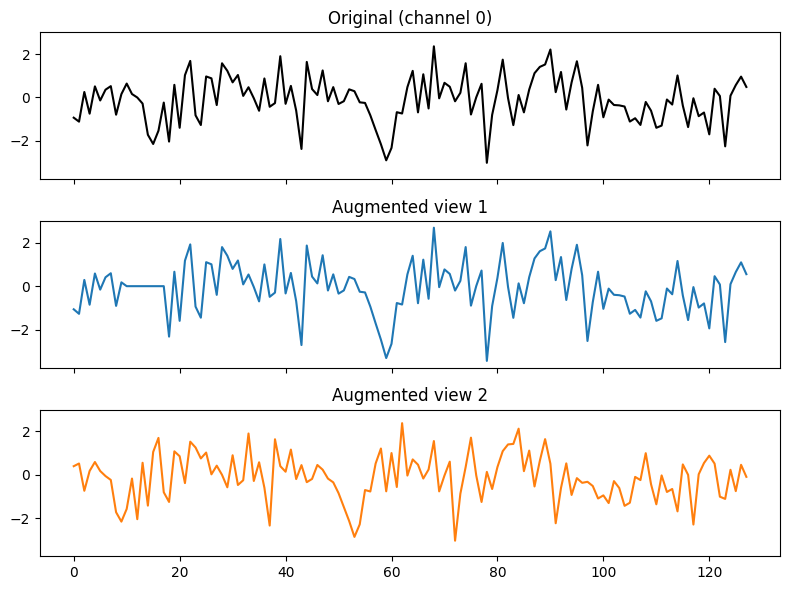

In [7]:

rng = np.random.default_rng(SEED)
example = X_train[0]
view1 = augment(example, rng=rng)
view2 = augment(example, rng=rng)

ch = 0
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True, sharey=True)
axes[0].plot(example[ch], color="black"); axes[0].set_title("Original (channel 0)")
axes[1].plot(view1[ch], color="tab:blue"); axes[1].set_title("Augmented view 1")
axes[2].plot(view2[ch], color="tab:orange"); axes[2].set_title("Augmented view 2")
plt.tight_layout()
plt.show()



## 8. Contrastive pretraining dataset

Wraps the **training-subject epochs only** (never test subjects, to avoid any leakage
into pretraining) and returns two independently augmented views per epoch, unlabeled.
Labels are not used at all in this stage — this is the self-supervised part of the
pipeline.


In [8]:

class ContrastiveEEGDataset(Dataset):
    def __init__(self, X, n_ops=2, seed=SEED):
        self.X = X
        self.n_ops = n_ops
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        v1 = augment(x, n_ops=self.n_ops, rng=self.rng)
        v2 = augment(x, n_ops=self.n_ops, rng=self.rng)
        return torch.from_numpy(v1.copy()).float(), torch.from_numpy(v2.copy()).float()


contrastive_ds = ContrastiveEEGDataset(X_train)
contrastive_loader = DataLoader(
    contrastive_ds, batch_size=CONFIG["PRETRAIN_BATCH_SIZE"], shuffle=True, drop_last=True
)
print(f"Contrastive pretraining set: {len(contrastive_ds)} epochs, "
      f"{len(contrastive_loader)} batches/epoch")


Contrastive pretraining set: 320 epochs, 10 batches/epoch



## 9. EEG encoder

A compact EEGNet-style convolutional encoder: a temporal convolution (learns
frequency-selective filters along time), a depthwise spatial convolution across channels
(learns spatial/channel-mixing filters, analogous to a spatial filter bank), a separable
convolution block, and global average pooling into a fixed-size embedding. This mirrors
the convolutional front-end used ahead of the attention layers in the existing
EEGConformer classifier, so the learned encoder here is architecturally comparable and
could later be substituted directly as EEGConformer's conv stem (see Kostas et al. 2021,
BENDR, for a transformer + contrastive combination along these lines).

Output: a single `EMBED_DIM`-dimensional embedding vector per epoch.


In [9]:

class EEGEncoder(nn.Module):
    def __init__(self, n_channels, n_times, f1=8, d=2, f2=16, embed_dim=64, dropout=0.3):
        super().__init__()
        self.temporal = nn.Sequential(
            nn.Conv2d(1, f1, kernel_size=(1, 25), padding=(0, 12), bias=False),
            nn.BatchNorm2d(f1),
        )
        self.spatial = nn.Sequential(
            nn.Conv2d(f1, f1 * d, kernel_size=(n_channels, 1), groups=f1, bias=False),
            nn.BatchNorm2d(f1 * d),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )
        self.separable = nn.Sequential(
            nn.Conv2d(f1 * d, f2, kernel_size=(1, 15), padding=(0, 7), groups=f1 * d, bias=False),
            nn.Conv2d(f2, f2, kernel_size=1, bias=False),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AdaptiveAvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )
        self.proj = nn.Linear(f2 * 8, embed_dim)

    def forward(self, x):
        # x: (batch, n_channels, n_times) -> (batch, 1, n_channels, n_times)
        x = x.unsqueeze(1)
        x = self.temporal(x)
        x = self.spatial(x)
        x = self.separable(x)
        x = x.flatten(1)
        x = self.proj(x)
        return x  # embedding, shape (batch, embed_dim)


class ProjectionHead(nn.Module):
    # SimCLR-style projection head, used only during contrastive pretraining.
    def __init__(self, embed_dim, proj_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embed_dim, proj_dim),
        )

    def forward(self, x):
        z = self.net(x)
        return F.normalize(z, dim=-1)


encoder = EEGEncoder(N_CHANNELS, N_TIMES, f1=CONFIG["F1"], d=CONFIG["D"], f2=CONFIG["F2"],
                      embed_dim=CONFIG["EMBED_DIM"]).to(DEVICE)
projector = ProjectionHead(CONFIG["EMBED_DIM"], CONFIG["PROJ_DIM"]).to(DEVICE)

n_params = sum(p.numel() for p in encoder.parameters())
print(f"Encoder parameters: {n_params:,}")


Encoder parameters: 9,496



## 10. NT-Xent (InfoNCE) contrastive loss

Standard SimCLR loss (Chen et al. 2020): for a batch of `N` epochs, both augmented views
are encoded and projected into `2N` normalized vectors. For each vector, the loss is a
softmax classification problem over the other `2N-1` vectors in the batch, where the
single positive is the *other view of the same epoch* and everything else counts as a
negative. Temperature `TEMPERATURE` controls how sharply the softmax penalizes
near-duplicate negatives.


In [10]:

def nt_xent_loss(z1, z2, temperature):
    N = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)  # (2N, proj_dim)
    sim = torch.mm(z, z.t()) / temperature  # (2N, 2N)

    mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, -1e9)

    positives = torch.cat([
        torch.arange(N, 2 * N, device=z.device),
        torch.arange(0, N, device=z.device),
    ])
    loss = F.cross_entropy(sim, positives)
    return loss



## 11. Canary overfit test (sanity check before full pretraining)

Before committing to a full pretraining run, confirm the training loop can actually learn
anything: overfit the contrastive objective on a tiny fixed batch. If the loss doesn't
drop well below `ln(2N-1)` (the loss of a model that can't tell positives from negatives
at all) within a few hundred steps, something is broken upstream (data loading, the loss
implementation, or the augmentations being too destructive) — worth checking before
spending time on a full run. This mirrors the canary-overfit debugging step already
planned for the supervised EEGConformer pipeline.


Chance-level loss (ln(2N-1)): 2.708
Canary loss after 300 steps: 0.060


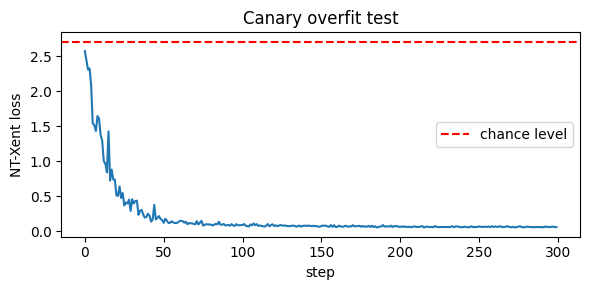

Canary test passed: training loop can learn.


In [11]:

tiny_n = min(8, len(contrastive_ds))
tiny_x1 = torch.stack([contrastive_ds[i][0] for i in range(tiny_n)]).to(DEVICE)
tiny_x2 = torch.stack([contrastive_ds[i][1] for i in range(tiny_n)]).to(DEVICE)

canary_encoder = EEGEncoder(N_CHANNELS, N_TIMES, f1=CONFIG["F1"], d=CONFIG["D"], f2=CONFIG["F2"],
                             embed_dim=CONFIG["EMBED_DIM"]).to(DEVICE)
canary_projector = ProjectionHead(CONFIG["EMBED_DIM"], CONFIG["PROJ_DIM"]).to(DEVICE)
canary_opt = torch.optim.Adam(list(canary_encoder.parameters()) + list(canary_projector.parameters()), lr=1e-3)

chance_loss = math.log(2 * tiny_n - 1)
losses = []
canary_encoder.train(); canary_projector.train()
for step in range(300):
    canary_opt.zero_grad()
    z1 = canary_projector(canary_encoder(tiny_x1))
    z2 = canary_projector(canary_encoder(tiny_x2))
    loss = nt_xent_loss(z1, z2, CONFIG["TEMPERATURE"])
    loss.backward()
    canary_opt.step()
    losses.append(loss.item())

print(f"Chance-level loss (ln(2N-1)): {chance_loss:.3f}")
print(f"Canary loss after 300 steps: {losses[-1]:.3f}")
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.axhline(chance_loss, color="red", linestyle="--", label="chance level")
plt.xlabel("step"); plt.ylabel("NT-Xent loss"); plt.legend(); plt.title("Canary overfit test")
plt.tight_layout(); plt.show()

assert losses[-1] < chance_loss * 0.5, (
    "Canary test did not overfit as expected - inspect the data/augmentation/loss pipeline "
    "before trusting a full pretraining run."
)
print("Canary test passed: training loop can learn.")



## 12. Full contrastive pretraining

Trains `encoder` + `projector` on all training-subject epochs (unlabeled) using the
NT-Xent loss and the augmentation pipeline above. Only `encoder` is kept afterward —
`projector` is SimCLR-specific scaffolding that is discarded once pretraining is done
(Chen et al. 2020 show the layer *before* the projection head transfers better to
downstream tasks than the projection output itself).


[pretrain] epoch  1/15  NT-Xent loss = 3.4400


[pretrain] epoch  2/15  NT-Xent loss = 3.0743


[pretrain] epoch  3/15  NT-Xent loss = 2.9059


[pretrain] epoch  4/15  NT-Xent loss = 2.8390


[pretrain] epoch  5/15  NT-Xent loss = 2.7032


...

[pretrain] epoch 11/15  NT-Xent loss = 2.5699


[pretrain] epoch 12/15  NT-Xent loss = 2.5827


[pretrain] epoch 13/15  NT-Xent loss = 2.5529


[pretrain] epoch 14/15  NT-Xent loss = 2.4951


[pretrain] epoch 15/15  NT-Xent loss = 2.5005


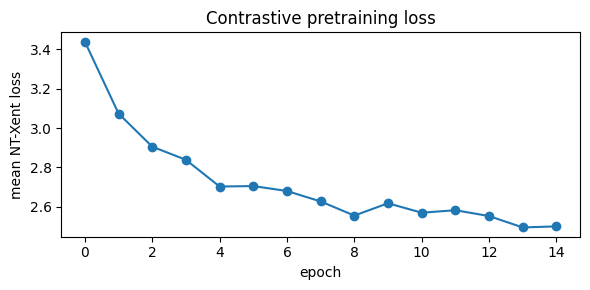

In [12]:

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(projector.parameters()), lr=CONFIG["PRETRAIN_LR"]
)

pretrain_losses = []
encoder.train(); projector.train()
for epoch in range(CONFIG["PRETRAIN_EPOCHS"]):
    epoch_losses = []
    for x1, x2 in contrastive_loader:
        x1, x2 = x1.to(DEVICE), x2.to(DEVICE)
        optimizer.zero_grad()
        z1 = projector(encoder(x1))
        z2 = projector(encoder(x2))
        loss = nt_xent_loss(z1, z2, CONFIG["TEMPERATURE"])
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    mean_loss = float(np.mean(epoch_losses))
    pretrain_losses.append(mean_loss)
    print(f"[pretrain] epoch {epoch + 1:2d}/{CONFIG['PRETRAIN_EPOCHS']}  NT-Xent loss = {mean_loss:.4f}")

plt.figure(figsize=(6, 3))
plt.plot(pretrain_losses, marker="o")
plt.xlabel("epoch"); plt.ylabel("mean NT-Xent loss"); plt.title("Contrastive pretraining loss")
plt.tight_layout(); plt.show()

pretrained_encoder_state = copy.deepcopy(encoder.state_dict())



## 13. Extract frozen embeddings for the labeled data

With the encoder frozen (`eval()`, no gradient), compute one embedding vector per epoch
for both the train and test splits. These feed the linear probe (Section 14) and the
embedding-space visualization (Section 17).


In [13]:

@torch.no_grad()
def get_embeddings(enc, X_arr, batch_size=64):
    enc.eval()
    embs = []
    for i in range(0, len(X_arr), batch_size):
        batch = torch.from_numpy(X_arr[i:i + batch_size]).float().to(DEVICE)
        embs.append(enc(batch).cpu().numpy())
    return np.concatenate(embs, axis=0)

encoder.load_state_dict(pretrained_encoder_state)
emb_train = get_embeddings(encoder, X_train)
emb_test = get_embeddings(encoder, X_test)
print("Train embeddings:", emb_train.shape, " Test embeddings:", emb_test.shape)


Train embeddings: (320, 64)  Test embeddings: (160, 64)



## 14. Linear evaluation protocol (frozen encoder + logistic regression)

The standard way to evaluate self-supervised representations (Chen et al. 2020): freeze
the encoder entirely and fit only a linear classifier on top. Good linear-probe accuracy
means the pretraining organized the embedding space by class-relevant structure, not just
by something the classifier can untangle with extra capacity. Evaluated two ways:

- Once on the single held-out-subjects test split from Section 5.
- Again with subject-grouped `StratifiedGroupKFold` cross-validation (matching the
  leave-one-subject-out-style protocol already used in the EEGConformer notebook) for a
  more robust estimate given the small number of subjects.


In [14]:

scaler = StandardScaler().fit(emb_train)
emb_train_s = scaler.transform(emb_train)
emb_test_s = scaler.transform(emb_test)

probe = LogisticRegression(max_iter=CONFIG["PROBE_MAX_ITER"], random_state=SEED)
probe.fit(emb_train_s, y_train)

probe_pred = probe.predict(emb_test_s)
probe_proba = probe.predict_proba(emb_test_s)[:, 1]

probe_acc = accuracy_score(y_test, probe_pred)
probe_auc = roc_auc_score(y_test, probe_proba) if len(np.unique(y_test)) > 1 else float("nan")

print(f"[Linear probe | held-out subjects] accuracy = {probe_acc:.3f}   AUC = {probe_auc:.3f}")
print(classification_report(y_test, probe_pred, target_names=["Size", "Animacy"]))
print("Confusion matrix:\n", confusion_matrix(y_test, probe_pred))


[Linear probe | held-out subjects] accuracy = 0.581   AUC = 0.560
              precision    recall  f1-score   support

        Size       0.55      0.45      0.50        73
     Animacy       0.60      0.69      0.64        87

    accuracy                           0.58       160
   macro avg       0.57      0.57      0.57       160
weighted avg       0.58      0.58      0.58       160

Confusion matrix:
 [[33 40]
 [27 60]]


In [15]:

n_splits = min(CONFIG["N_CV_FOLDS"], len(np.unique(groups)) - 1)
n_splits = max(n_splits, 2)
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

cv_accs, cv_aucs = [], []
for fold, (tr_idx, va_idx) in enumerate(sgkf.split(emb_train, y_train, g_train)):
    sc = StandardScaler().fit(emb_train[tr_idx])
    clf = LogisticRegression(max_iter=CONFIG["PROBE_MAX_ITER"], random_state=SEED)
    clf.fit(sc.transform(emb_train[tr_idx]), y_train[tr_idx])
    pred = clf.predict(sc.transform(emb_train[va_idx]))
    proba = clf.predict_proba(sc.transform(emb_train[va_idx]))[:, 1]
    acc = accuracy_score(y_train[va_idx], pred)
    auc = roc_auc_score(y_train[va_idx], proba) if len(np.unique(y_train[va_idx])) > 1 else float("nan")
    cv_accs.append(acc); cv_aucs.append(auc)
    print(f"[CV fold {fold + 1}/{n_splits}] acc = {acc:.3f}  auc = {auc:.3f}")

print(f"\nLinear probe CV (within training subjects): "
      f"acc = {np.nanmean(cv_accs):.3f} +/- {np.nanstd(cv_accs):.3f}   "
      f"auc = {np.nanmean(cv_aucs):.3f} +/- {np.nanstd(cv_aucs):.3f}")


[CV fold 1/4] acc = 0.500  auc = 0.532
[CV fold 2/4] acc = 0.500  auc = 0.496
[CV fold 3/4] acc = 0.512  auc = 0.473
[CV fold 4/4] acc = 0.562  auc = 0.556

Linear probe CV (within training subjects): acc = 0.519 +/- 0.026   auc = 0.514 +/- 0.032



## 15. End-to-end fine-tuning

Unfreezes the pretrained encoder, attaches a small classifier head, and trains the whole
thing end-to-end on the labeled training epochs with a **small learning rate** (fine-tune
LR is 10x lower than the baseline's from-scratch LR) to avoid destroying the pretrained
representation early in training. Evaluated on the same held-out subjects as the linear
probe for a direct comparison.


In [16]:

class EEGClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, n_classes=2):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(embed_dim, n_classes)

    def forward(self, x):
        z = self.encoder(x)
        return self.head(z)


class LabeledEEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]).float(), int(self.y[idx])


finetune_encoder = EEGEncoder(N_CHANNELS, N_TIMES, f1=CONFIG["F1"], d=CONFIG["D"], f2=CONFIG["F2"],
                               embed_dim=CONFIG["EMBED_DIM"]).to(DEVICE)
finetune_encoder.load_state_dict(pretrained_encoder_state)
finetune_model = EEGClassifier(finetune_encoder, CONFIG["EMBED_DIM"]).to(DEVICE)

train_ds = LabeledEEGDataset(X_train, y_train)
test_ds = LabeledEEGDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=CONFIG["FINETUNE_BATCH_SIZE"], shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

ft_optimizer = torch.optim.Adam(finetune_model.parameters(), lr=CONFIG["FINETUNE_LR"])
ft_criterion = nn.CrossEntropyLoss()

ft_losses = []
finetune_model.train()
for epoch in range(CONFIG["FINETUNE_EPOCHS"]):
    epoch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        ft_optimizer.zero_grad()
        logits = finetune_model(xb)
        loss = ft_criterion(logits, yb)
        loss.backward()
        ft_optimizer.step()
        epoch_losses.append(loss.item())
    mean_loss = float(np.mean(epoch_losses))
    ft_losses.append(mean_loss)
    print(f"[finetune] epoch {epoch + 1:2d}/{CONFIG['FINETUNE_EPOCHS']}  CE loss = {mean_loss:.4f}")

@torch.no_grad()
def evaluate_torch_classifier(model, loader):
    model.eval()
    all_pred, all_proba, all_true = [], [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        proba = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        pred = logits.argmax(dim=-1).cpu().numpy()
        all_pred.append(pred); all_proba.append(proba); all_true.append(yb.numpy())
    return np.concatenate(all_true), np.concatenate(all_pred), np.concatenate(all_proba)

yt, yp, yproba = evaluate_torch_classifier(finetune_model, test_loader)
ft_acc = accuracy_score(yt, yp)
ft_auc = roc_auc_score(yt, yproba) if len(np.unique(yt)) > 1 else float("nan")
print(f"\n[Fine-tuned | held-out subjects] accuracy = {ft_acc:.3f}   AUC = {ft_auc:.3f}")
print(classification_report(yt, yp, target_names=["Size", "Animacy"]))


[finetune] epoch  1/10  CE loss = 0.7006


[finetune] epoch  2/10  CE loss = 0.6974


[finetune] epoch  3/10  CE loss = 0.6987


[finetune] epoch  4/10  CE loss = 0.6932


[finetune] epoch  5/10  CE loss = 0.6882


[finetune] epoch  6/10  CE loss = 0.6947


[finetune] epoch  7/10  CE loss = 0.6894


[finetune] epoch  8/10  CE loss = 0.6827


[finetune] epoch  9/10  CE loss = 0.6875


[finetune] epoch 10/10  CE loss = 0.6858

[Fine-tuned | held-out subjects] accuracy = 0.456   AUC = 0.489
              precision    recall  f1-score   support

        Size       0.45      0.93      0.61        73
     Animacy       0.50      0.06      0.10        87

    accuracy                           0.46       160
   macro avg       0.48      0.49      0.36       160
weighted avg       0.48      0.46      0.33       160




## 16. Supervised baseline (same architecture, no contrastive pretraining)

Trains an identical `EEGEncoder` + classifier head **from random initialization**,
purely supervised, on the same train/test split. This isolates the effect of contrastive
pretraining: if linear-probe / fine-tuned accuracy above beats this baseline, the
pretraining is adding real value; if not, the bottleneck is more likely upstream
(data/label alignment, signal quality) rather than representation learning — directly
relevant to the chance-level results seen with the supervised EEGConformer pipeline.


In [17]:

baseline_encoder = EEGEncoder(N_CHANNELS, N_TIMES, f1=CONFIG["F1"], d=CONFIG["D"], f2=CONFIG["F2"],
                               embed_dim=CONFIG["EMBED_DIM"]).to(DEVICE)
baseline_model = EEGClassifier(baseline_encoder, CONFIG["EMBED_DIM"]).to(DEVICE)

bl_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=CONFIG["BASELINE_LR"])
bl_criterion = nn.CrossEntropyLoss()

baseline_train_loader = DataLoader(train_ds, batch_size=CONFIG["BASELINE_BATCH_SIZE"], shuffle=True)

baseline_model.train()
for epoch in range(CONFIG["BASELINE_EPOCHS"]):
    epoch_losses = []
    for xb, yb in baseline_train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        bl_optimizer.zero_grad()
        logits = baseline_model(xb)
        loss = bl_criterion(logits, yb)
        loss.backward()
        bl_optimizer.step()
        epoch_losses.append(loss.item())
    print(f"[baseline] epoch {epoch + 1:2d}/{CONFIG['BASELINE_EPOCHS']}  "
          f"CE loss = {np.mean(epoch_losses):.4f}")

yt_b, yp_b, yproba_b = evaluate_torch_classifier(baseline_model, test_loader)
baseline_acc = accuracy_score(yt_b, yp_b)
baseline_auc = roc_auc_score(yt_b, yproba_b) if len(np.unique(yt_b)) > 1 else float("nan")
print(f"\n[Supervised baseline | held-out subjects] accuracy = {baseline_acc:.3f}   AUC = {baseline_auc:.3f}")


[baseline] epoch  1/15  CE loss = 0.6926


[baseline] epoch  2/15  CE loss = 0.6497


[baseline] epoch  3/15  CE loss = 0.5985


[baseline] epoch  4/15  CE loss = 0.5115


[baseline] epoch  5/15  CE loss = 0.4000


...

[baseline] epoch 11/15  CE loss = 0.0518


[baseline] epoch 12/15  CE loss = 0.0332


[baseline] epoch 13/15  CE loss = 0.0219


[baseline] epoch 14/15  CE loss = 0.0140


[baseline] epoch 15/15  CE loss = 0.0131

[Supervised baseline | held-out subjects] accuracy = 0.988   AUC = 1.000



## 17. Results comparison and embedding visualization

- **Bar chart**: accuracy and AUC for the supervised baseline vs. contrastive + linear
  probe vs. contrastive + fine-tuning, all on the same held-out subjects.
- **t-SNE of the pretrained embeddings**: colored by class label (does the contrastive
  space separate Size vs. Animacy at all?) and by subject (is the space dominated by
  subject identity — a known EEG confound — rather than task?). A useful representation
  should show *some* label structure and *not* be perfectly clustered by subject.


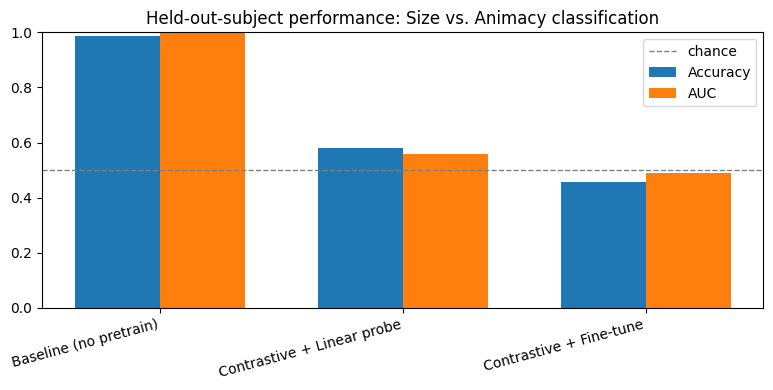

Baseline (no pretrain)         acc=0.988  auc=1.000
Contrastive + Linear probe     acc=0.581  auc=0.560
Contrastive + Fine-tune        acc=0.456  auc=0.489


In [18]:

results = {
    "Baseline (no pretrain)": (baseline_acc, baseline_auc),
    "Contrastive + Linear probe": (probe_acc, probe_auc),
    "Contrastive + Fine-tune": (ft_acc, ft_auc),
}

labels = list(results.keys())
accs = [results[k][0] for k in labels]
aucs = [results[k][1] for k in labels]

x_pos = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos - width / 2, accs, width, label="Accuracy")
ax.bar(x_pos + width / 2, aucs, width, label="AUC")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="chance")
ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Held-out-subject performance: Size vs. Animacy classification")
plt.tight_layout(); plt.show()

for k, (a, u) in results.items():
    print(f"{k:30s} acc={a:.3f}  auc={u:.3f}")


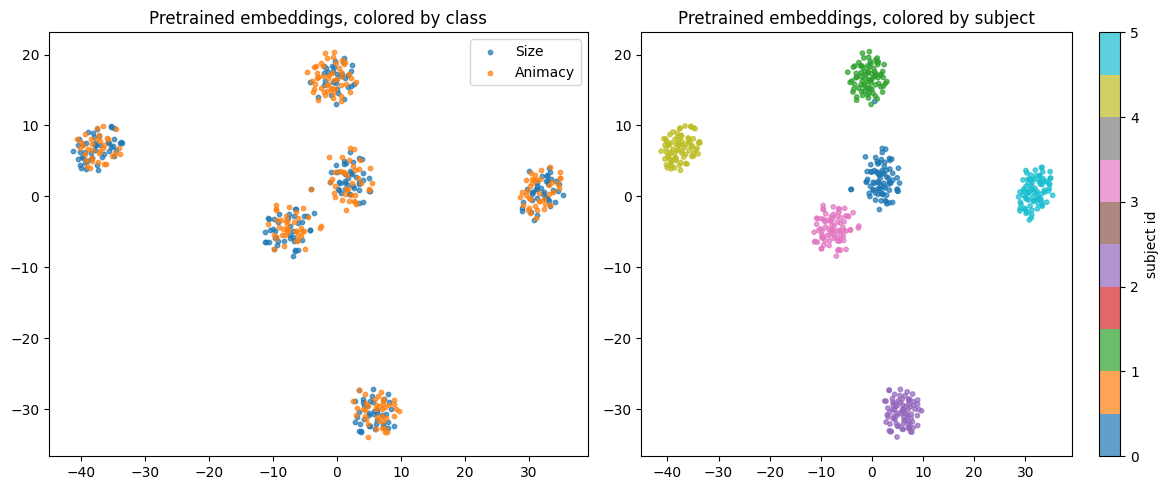

In [19]:

all_emb = np.concatenate([emb_train, emb_test], axis=0)
all_y = np.concatenate([y_train, y_test])
all_g = np.concatenate([g_train, g_test])

tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, max(5, len(all_emb) // 4 - 1)))
emb_2d = tsne.fit_transform(all_emb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for c, name in zip([0, 1], ["Size", "Animacy"]):
    m = all_y == c
    axes[0].scatter(emb_2d[m, 0], emb_2d[m, 1], s=10, label=name, alpha=0.7)
axes[0].legend(); axes[0].set_title("Pretrained embeddings, colored by class")

sc = axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], s=10, c=all_g, cmap="tab10", alpha=0.7)
axes[1].set_title("Pretrained embeddings, colored by subject")
plt.colorbar(sc, ax=axes[1], label="subject id")

plt.tight_layout(); plt.show()



## 18. Summary and interpretation

- If **Contrastive + Linear probe** clearly beats the **Baseline**, the pretrained
  embedding space already organizes epochs by task-relevant structure without ever seeing
  labels — strong evidence that contrastive pretraining is adding real value, not just
  extra capacity.
- If **Fine-tune** beats **Linear probe**, allowing the encoder to adapt end-to-end
  captures additional task-relevant structure beyond what the frozen representation
  offers — expected when there is enough labeled data to fine-tune safely.
- If **all three results sit at chance** (~0.5 accuracy/AUC, matching the previous
  EEGConformer results), that is further evidence the bottleneck is upstream of the model
  entirely — most likely epoch/label alignment or signal quality — since even a
  self-supervised approach with no label-noise sensitivity during pretraining fails to
  separate the classes.
- The subject-colored t-SNE plot is worth inspecting on its own: if embeddings cluster
  tightly by subject rather than by class, that's a concrete, visual confirmation of the
  known cross-subject generalization problem in EEG, and motivates adding subject-invariance
  objectives (e.g., a subject-adversarial term, or the subject-invariant contrastive setup
  in Han et al., *Contrastive Learning of Subject-Invariant EEG Representations*, 2021) as
  a next step.

**Practical next steps if this is run on the real preprocessed data:**

1. Set `DATA_PATH` to the actual `.npz` from the preprocessing notebook and re-run.
2. If results remain at chance, re-run the Section 4 QC cell on the real data first —
   the canary test here only validates the *training loop*, not label alignment.
3. Increase `PRETRAIN_EPOCHS` / pretrain on more unlabeled epochs (e.g., include
   non-task resting-state EEG if available) once the pipeline is confirmed working.
4. Consider swapping `EEGEncoder` for the convolutional stem of the existing
   EEGConformer model to keep the encoder architecture identical across the supervised
   and contrastive pipelines for a cleaner comparison.
